<a href="https://colab.research.google.com/github/PA-Pal601/IBM-SkillsBuild-Fake-News-Detector-for-Students/blob/main/Fake_News_Detector_for_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Fake News Detector for Students


##  1: Install & Import Libraries

In [1]:
# ── Install required packages ──────────────────────────────────────────────
!pip install -q nltk textblob wordcloud scikit-learn matplotlib seaborn pandas numpy requests beautifulsoup4

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ All packages installed and ready!")

✅ All packages installed and ready!


In [2]:
# ── Core Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re
import string
import textwrap
from collections import Counter

warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Visualization
from wordcloud import WordCloud

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3d4166',
    'axes.labelcolor': '#e0e0ff',
    'xtick.color': '#a0a0cc',
    'ytick.color': '#a0a0cc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2d4a',
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans'
})

print("✅ All libraries imported successfully!")
print(f"📊 Scikit-learn, NLTK, TextBlob, Matplotlib ready.")

✅ All libraries imported successfully!
📊 Scikit-learn, NLTK, TextBlob, Matplotlib ready.


---
##  2: Dataset Creation & Loading

We create a **realistic synthetic dataset** of real vs fake news articles covering common student topics. In a production system, you'd use datasets like [LIAR](https://paperswithcode.com/dataset/liar) or [FakeNewsNet](https://github.com/KaiDMML/FakeNewsNet).

In [3]:
# ── Build Synthetic Dataset ────────────────────────────────────────────────

real_news = [
    # Science & Health
    "Scientists at WHO confirm that vaccines undergo rigorous clinical trials across three phases before approval. Studies involving tens of thousands of participants validate both safety and efficacy data.",
    "Researchers at MIT published findings in Nature journal showing that regular physical exercise reduces the risk of cardiovascular disease by 35 percent over a 10-year period.",
    "The Indian Space Research Organisation successfully launched the Chandrayaan-3 mission, achieving a soft landing near the lunar south pole in August 2023.",
    "According to the World Health Organization, hand washing with soap for at least 20 seconds reduces transmission of respiratory infections by up to 21 percent.",
    "NASA's James Webb Space Telescope has captured the deepest infrared images of the universe, revealing galaxies formed just 300 million years after the Big Bang.",
    "A peer-reviewed study in The Lancet found that Mediterranean diet adherence is associated with a significant reduction in cognitive decline in adults over 60.",
    "Climate scientists from 195 countries reached consensus in the IPCC 2023 report that global temperatures have risen 1.1°C above pre-industrial levels due to human activity.",
    "Researchers at Oxford University developed a malaria vaccine showing 77% efficacy in Phase 3 trials conducted across four African countries.",
    "The Reserve Bank of India raised the repo rate by 25 basis points to 6.5% in its February 2023 meeting to control inflation.",
    "According to UNICEF data, global child mortality rates have dropped by more than 50% since 1990 due to improved healthcare and vaccination programs.",

    # Technology
    "Google DeepMind's AlphaFold 2 has predicted the 3D structures of over 200 million proteins, covering nearly all known proteins on Earth, significantly accelerating drug discovery.",
    "The Indian government launched the Digital India initiative to connect rural areas with high-speed internet, targeting 6 lakh villages under the BharatNet project.",
    "Researchers from Stanford University published a study showing that AI models trained on diverse datasets perform better and show less bias in natural language understanding tasks.",
    "Electric vehicle sales in India grew by 49% in 2022-23, with over 1 million units sold, driven by government subsidies under the FAME-II scheme.",
    "Microsoft's Azure cloud platform reported 27% revenue growth in Q1 2024, with significant contributions from AI and machine learning services.",

    # Education & Social
    "The National Education Policy 2020 introduces multidisciplinary education, flexible curriculum, and emphasis on vocational training from Grade 6 in Indian schools.",
    "According to the Annual Status of Education Report, reading levels among primary school children in rural India showed improvement after targeted intervention programs.",
    "Studies published in the Journal of Educational Psychology indicate that spaced repetition improves long-term retention of information by up to 80% compared to massed practice.",
    "The Supreme Court of India ruled that the Right to Education Act mandates free and compulsory education for children aged 6 to 14 years in all recognized schools.",
    "United Nations reports show that access to quality education for girls in South Asia has improved by 15 percentage points over the last decade.",

    # Environment
    "India committed to achieving net-zero carbon emissions by 2070 and increasing its renewable energy capacity to 500 GW by 2030 at the COP26 summit.",
    "A study in Science journal documented that Arctic sea ice is declining at a rate of 13% per decade, with the summer minimum reaching record lows in 2023.",
    "The Forest Survey of India reported a net increase of 1,540 sq km in forest cover between 2019 and 2021, though experts note concerns about forest quality.",
    "Renewable energy sources including solar and wind now account for over 30% of electricity generation in India as of March 2024.",
    "Marine biologists confirmed that coral reefs in the Lakshadweep Islands experienced bleaching events due to rising ocean temperatures in 2023.",

    # Economy
    "India's GDP grew at 7.2% in FY2022-23, making it one of the fastest-growing major economies, according to the National Statistical Office.",
    "The World Bank projects India's economy to grow at 6.4% in 2024-25, supported by strong domestic consumption and government capital expenditure.",
    "India's Unified Payments Interface processed over 10 billion transactions in a single month for the first time in August 2023, according to NPCI data.",
    "The unemployment rate in India stood at 7.45% in December 2023, according to the Centre for Monitoring Indian Economy's monthly tracker.",
    "Foreign direct investment into India declined to $71 billion in 2022-23 from $84 billion in 2021-22, according to the Department for Promotion of Industry and Internal Trade.",
]

fake_news = [
    # Health Misinformation
    "SHOCKING: Scientists PROVE vaccines contain microchips that track your location!! Government hiding this truth from everyone. Share before it gets deleted!!!",
    "BREAKING: Drinking bleach cures COVID-19 instantly! Big Pharma doesn't want you to know this ANCIENT SECRET remedy that doctors are forbidden to share!",
    "5G towers are SPREADING coronavirus! Microwave radiation activates the virus implanted in vaccines. Thousands dying and media covers it up completely!",
    "MIRACLE CURE: Eating raw garlic every hour ELIMINATES all cancers in 3 days! Oncologists FURIOUS that this simple cure is being shared online!",
    "Scientists secretly ADMIT that the moon landing was FAKED! Newly leaked NASA documents reveal the ENTIRE space program is a multi-billion dollar Hollywood hoax!",
    "URGENT: Fluoride in drinking water lowers your IQ by 40 points! Government using water supply to control population and suppress intelligence of citizens!",
    "EXPOSED: Sunscreen causes skin cancer NOT the sun! Chemical companies pay doctors to hide this! Stop using sunscreen immediately to protect yourself!",
    "This viral video PROVES that earth is flat and NASA uses CGI for all space images. Pilots confirm they NEVER adjust for curvature. Wake up sheeple!",
    "Scientists CONFIRM that eating chocolate daily CURES diabetes! One weird trick doctors hate! Big pharma blocking this $5 cure from reaching the public!",
    "BOMBSHELL: Hospitals paid $50,000 per COVID death to inflate numbers! Doctors ordered to list all deaths as COVID! This is GENOCIDE by the elite!",

    # Political Misinformation
    "ELECTION FRAUD PROVEN! Thousands of votes switched by software in 12 states! Foreign hackers changed results! The whole election was STOLEN!",
    "Secret globalist cabal controls all world governments!! Illuminati members confirmed in leaked document showing names of politicians who sold out their country!",
    "Government secretly SPRAYING chemicals from planes (chemtrails) to make people sick and reduce population! Former pilot confesses EVERYTHING on deathbed!",
    "EXPOSED: Famous politician secretly reptilian alien! Video analysis proves shape-shifting caught on camera during live interview! Share before YouTube deletes!",
    "INSIDER reveals that all mainstream media is scripted by ONE company!! Every news channel reads EXACT same words!! Proof they control your mind!",

    # Financial Scams
    "GUARANTEED: Invest Rs 1000 today and get Rs 10 LAKH in 30 days!! This secret investment method used by billionaires is FINALLY available to common people!",
    "Bitcoin will hit $1 MILLION by next month! Insider tip from anonymous Wall Street source! Buy everything now or miss the ONLY chance to become rich!",
    "Nigerian prince needs urgent help transferring $50 million! Will share 30% as reward! Only need your bank details to process urgent international transfer!",
    "Work from home and earn Rs 50,000 daily just by clicking ads for 2 hours! No skills needed! Hundreds of students already earning crores from this method!",
    "SHOCKING: India will switch to gold standard next month! RBI Governor secretly told us! Buy gold NOW before rupee becomes worthless within weeks!",

    # Student-targeted Misinformation
    "IIT and IIM admissions can be BOUGHT for Rs 5 lakhs! Secret agent confirms bribery network! Hard work is USELESS, it's all about who you know!",
    "PROVEN: Reading under dim light does NOT damage eyesight - this was made up by opticians to sell glasses! Parents and teachers lied to you your whole life!",
    "Einstein FAILED math in school - so stop studying! Grades don't matter at all! Bill Gates and Zuckerberg prove college is a COMPLETE WASTE of time!",
    "URGENT: WhatsApp will start charging Rs 500/month from next week unless you forward this message to 20 contacts! Forward NOW to keep your account free!",
    "Scientists discover that humans only use 10% of their brain! Taking this supplement UNLOCKS remaining 90% and makes you a GENIUS overnight!",

    # Environment Misinformation
    "Climate change is a HOAX invented by globalists to destroy industrial economies! 31,000 scientists signed petition saying CO2 is harmless plant food!",
    "BREAKING: Solar panels cause more pollution than coal! Secret study suppressed by green energy companies proves renewable energy is actually TOXIC!",
    "Plastic pollution crisis is FAKE NEWS! Ocean plastic actually helps fish build homes! Environmentalists making up crisis to get government grants!",
    "EXPOSED: Electric vehicles actually produce MORE carbon than petrol cars when you count battery production! Green energy is the BIGGEST scam of the century!",
    "Pesticides are GOOD for you and make food more nutritious! Organic food movement is a SCAM by elites to make healthy food unaffordable for poor people!",
]

# ── Compile into DataFrame ─────────────────────────────────────────────────
df_real = pd.DataFrame({'text': real_news, 'label': 'REAL', 'label_num': 0})
df_fake = pd.DataFrame({'text': fake_news, 'label': 'FAKE', 'label_num': 1})
df = pd.concat([df_real, df_fake], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Dataset created successfully!")
print(f"📰 Total Articles : {len(df)}")
print(f"✔️  Real News      : {len(df_real)}")
print(f"❌ Fake News      : {len(df_fake)}")
df.head()

✅ Dataset created successfully!
📰 Total Articles : 60
✔️  Real News      : 30
❌ Fake News      : 30


,text,label,label_num
0,Scientists at WHO confirm that vaccines underg...,REAL,0
1,A peer-reviewed study in The Lancet found that...,REAL,0
2,EXPOSED: Sunscreen causes skin cancer NOT the ...,FAKE,1
3,GUARANTEED: Invest Rs 1000 today and get Rs 10...,FAKE,1
4,Electric vehicle sales in India grew by 49% in...,REAL,0


---
##  3: Exploratory Data Analysis (EDA)

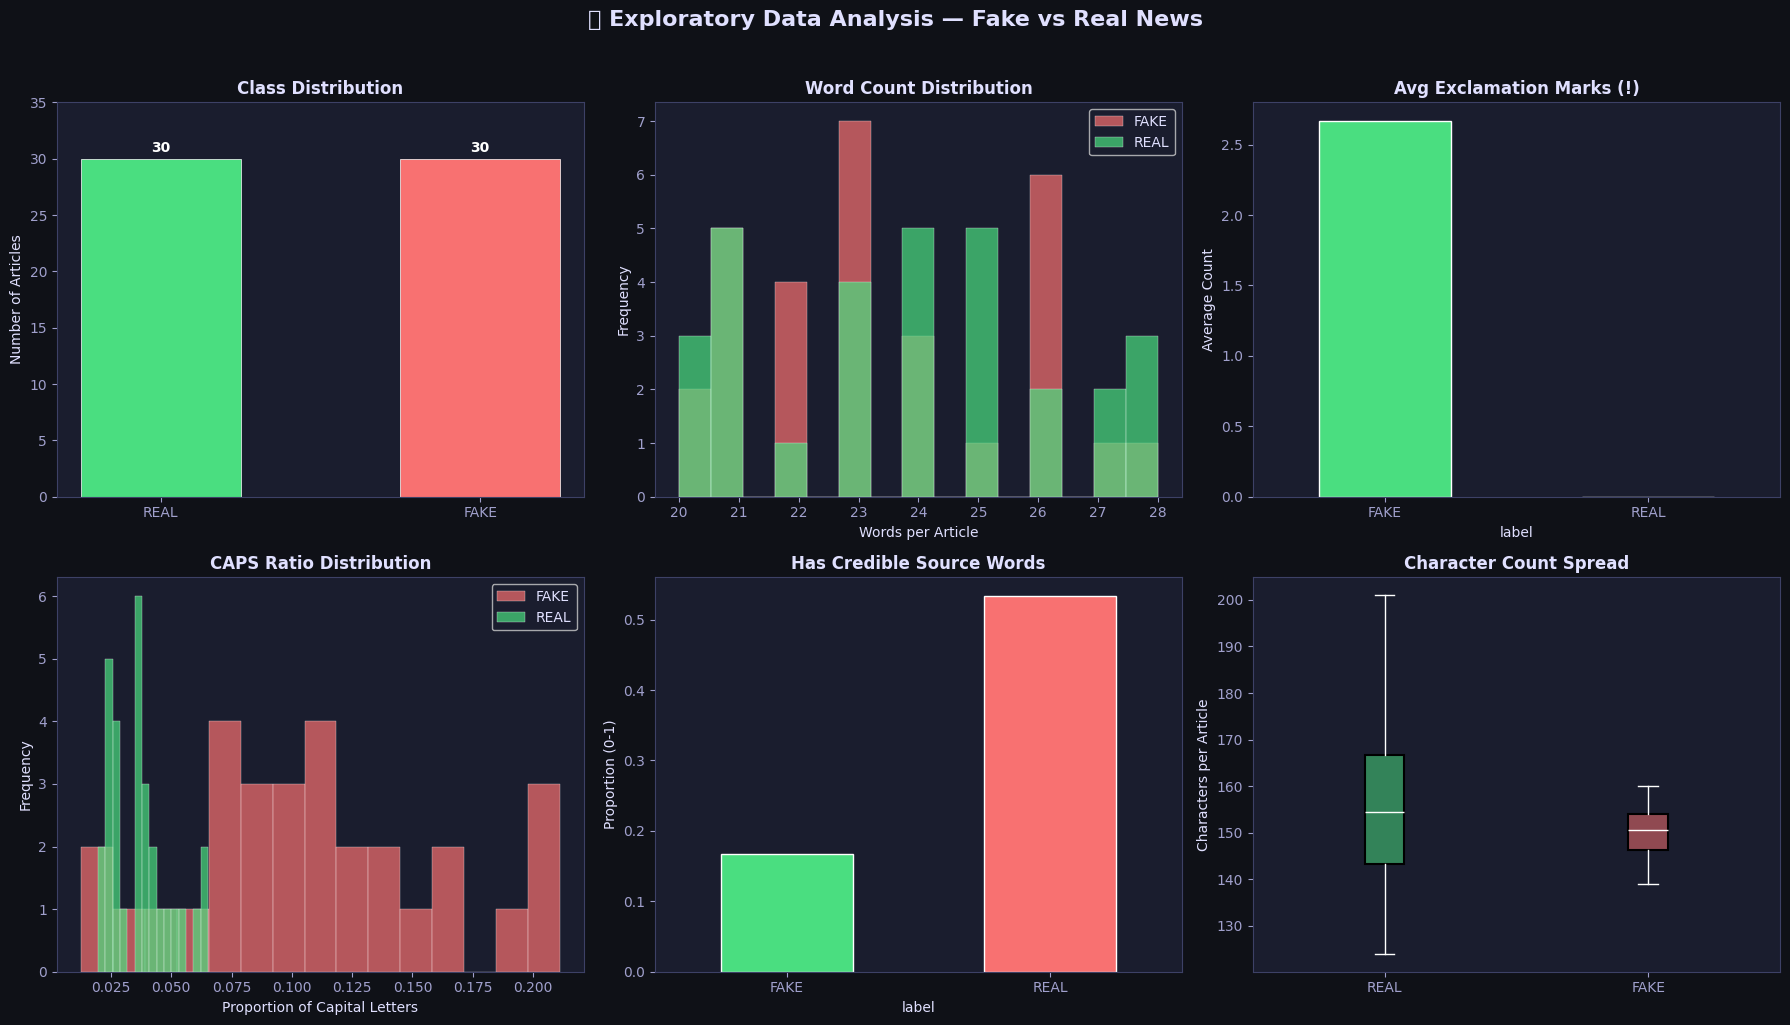


📈 Key Observations:
   • Fake news uses 2.7x more exclamation marks on average
   • Fake news has 11.0% CAPS vs 3.7% in real news
   • Real news cites credible sources 53% of the time


In [4]:
# ── EDA: Distribution & Text Statistics ───────────────────────────────────

df['word_count']      = df['text'].apply(lambda x: len(x.split()))
df['char_count']      = df['text'].apply(len)
df['exclamation']     = df['text'].apply(lambda x: x.count('!'))
df['question_marks']  = df['text'].apply(lambda x: x.count('?'))
df['caps_ratio']      = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
df['has_numbers']     = df['text'].apply(lambda x: int(bool(re.search(r'\d+\.?\d*\s*(%|percent)', x, re.I))))
df['source_words']    = df['text'].apply(lambda x: int(bool(re.search(r'\b(journal|published|research|study|according|WHO|NASA|ISRO|university|institute)\b', x, re.I))))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Exploratory Data Analysis — Fake vs Real News', fontsize=16, fontweight='bold', color='#e0e0ff', y=1.02)

colors = {'REAL': '#4ade80', 'FAKE': '#f87171'}

# 1. Class Distribution
ax = axes[0, 0]
counts = df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#4ade80', '#f87171'], width=0.5, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center', va='bottom', fontweight='bold', color='white')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Number of Articles')
ax.set_ylim(0, max(counts) + 5)

# 2. Word Count Distribution
ax = axes[0, 1]
for label, grp in df.groupby('label'):
    ax.hist(grp['word_count'], bins=15, alpha=0.7, label=label, color=colors[label], edgecolor='white', linewidth=0.3)
ax.set_title('Word Count Distribution', fontweight='bold')
ax.set_xlabel('Words per Article')
ax.set_ylabel('Frequency')
ax.legend()

# 3. Exclamation Marks
ax = axes[0, 2]
df.groupby('label')['exclamation'].mean().plot(kind='bar', ax=ax, color=['#4ade80', '#f87171'], edgecolor='white')
ax.set_title('Avg Exclamation Marks (!)', fontweight='bold')
ax.set_ylabel('Average Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 4. CAPS Ratio
ax = axes[1, 0]
for label, grp in df.groupby('label'):
    ax.hist(grp['caps_ratio'], bins=15, alpha=0.7, label=label, color=colors[label], edgecolor='white', linewidth=0.3)
ax.set_title('CAPS Ratio Distribution', fontweight='bold')
ax.set_xlabel('Proportion of Capital Letters')
ax.set_ylabel('Frequency')
ax.legend()

# 5. Source Citation Words
ax = axes[1, 1]
df.groupby('label')['source_words'].mean().plot(kind='bar', ax=ax, color=['#4ade80', '#f87171'], edgecolor='white')
ax.set_title('Has Credible Source Words', fontweight='bold')
ax.set_ylabel('Proportion (0-1)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 6. Char Count Boxplot
ax = axes[1, 2]
real_chars = df[df['label'] == 'REAL']['char_count']
fake_chars = df[df['label'] == 'FAKE']['char_count']
bp = ax.boxplot([real_chars, fake_chars], labels=['REAL', 'FAKE'], patch_artist=True,
                boxprops=dict(linewidth=1.5))
bp['boxes'][0].set_facecolor('#4ade8088')
bp['boxes'][1].set_facecolor('#f8717188')
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    plt.setp(bp[element], color='white')
ax.set_title('Character Count Spread', fontweight='bold')
ax.set_ylabel('Characters per Article')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n📈 Key Observations:")
print(f"   • Fake news uses {df[df['label']=='FAKE']['exclamation'].mean():.1f}x more exclamation marks on average")
print(f"   • Fake news has {df[df['label']=='FAKE']['caps_ratio'].mean()*100:.1f}% CAPS vs {df[df['label']=='REAL']['caps_ratio'].mean()*100:.1f}% in real news")
print(f"   • Real news cites credible sources {df[df['label']=='REAL']['source_words'].mean()*100:.0f}% of the time")

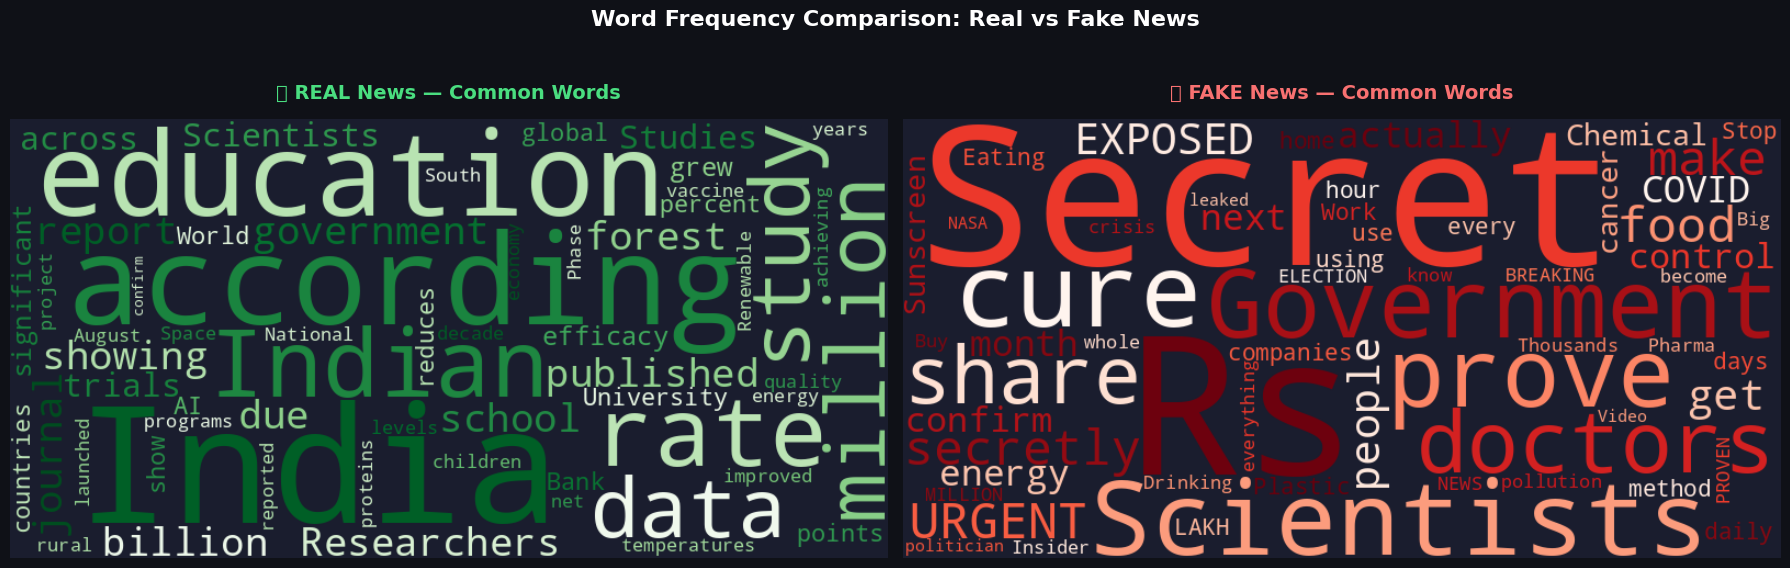

In [5]:
# ── WordCloud Comparison ───────────────────────────────────────────────────

stop_words = set(stopwords.words('english'))
extra_stops = {'said', 'say', 'also', 'one', 'us', 'would', 'could', 'may', 'new', 'year'}
stop_words.update(extra_stops)

real_text = ' '.join(df[df['label'] == 'REAL']['text'])
fake_text = ' '.join(df[df['label'] == 'FAKE']['text'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#0f1117')

wc_real = WordCloud(
    width=800, height=400, background_color='#1a1d2e',
    colormap='Greens', stopwords=stop_words,
    max_words=60, collocations=False
).generate(real_text)

wc_fake = WordCloud(
    width=800, height=400, background_color='#1a1d2e',
    colormap='Reds', stopwords=stop_words,
    max_words=60, collocations=False
).generate(fake_text)

axes[0].imshow(wc_real, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('✅ REAL News — Common Words', fontsize=14, fontweight='bold', color='#4ade80', pad=15)

axes[1].imshow(wc_fake, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('❌ FAKE News — Common Words', fontsize=14, fontweight='bold', color='#f87171', pad=15)

plt.suptitle('Word Frequency Comparison: Real vs Fake News', fontsize=16, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('wordcloud_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 4: Text Preprocessing & Feature Engineering

In [6]:
# ── Text Preprocessing ─────────────────────────────────────────────────────

lemmatizer = WordNetLemmatizer()
stop_words_list = set(stopwords.words('english'))

def preprocess_text(text):
    """Full NLP pipeline: clean → tokenize → remove stopwords → lemmatize"""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)           # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)                # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()             # Normalize whitespace
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words_list and len(t) > 2]
    return ' '.join(tokens)

def get_sentiment(text):
    """Get sentiment polarity using TextBlob"""
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

# Apply preprocessing
print("⚙️  Preprocessing text...")
df['clean_text'] = df['text'].apply(preprocess_text)

# Sentiment features
sentiments = df['text'].apply(get_sentiment)
df['sentiment_polarity']     = [s[0] for s in sentiments]
df['sentiment_subjectivity'] = [s[1] for s in sentiments]

# Linguistic red-flag features
df['clickbait_words'] = df['text'].apply(
    lambda x: len(re.findall(r'\b(shocking|bombshell|exposed|secret|urgent|breaking|proof|hoax|conspiracy|wake up|share before|hidden|miracle|cure|guaranteed)\b', x, re.I))
)
df['credibility_words'] = df['text'].apply(
    lambda x: len(re.findall(r'\b(according to|published|study|research|journal|percent|data|report|evidence|university|institute|peer.reviewed)\b', x, re.I))
)

print("✅ Preprocessing complete!")
print("\n📊 Feature Engineering Summary:")
print(df[['label', 'sentiment_polarity', 'sentiment_subjectivity', 'clickbait_words', 'credibility_words', 'exclamation', 'caps_ratio']]
      .groupby('label').mean().round(3))

⚙️  Preprocessing text...
✅ Preprocessing complete!

📊 Feature Engineering Summary:
       sentiment_polarity  sentiment_subjectivity  clickbait_words  \
label                                                                
FAKE               -0.088                   0.406            0.933   
REAL                0.099                   0.271            0.000   

       credibility_words  exclamation  caps_ratio  
label                                              
FAKE               0.033        2.667       0.110  
REAL               0.900        0.000       0.037  


---
##  5: Model Training & Evaluation

In [7]:
# ── Train-Test Split & TF-IDF Vectorization ────────────────────────────────

X = df['clean_text']
y = df['label_num']  # 0=REAL, 1=FAKE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),     # Unigrams + Bigrams
    min_df=1,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"📐 Training set size   : {X_train.shape[0]} articles")
print(f"📐 Test set size       : {X_test.shape[0]} articles")
print(f"📐 TF-IDF feature dim  : {X_train_tfidf.shape[1]} features")

📐 Training set size   : 45 articles
📐 Test set size       : 15 articles
📐 TF-IDF feature dim  : 1181 features


In [8]:
# ── Train Multiple Models & Compare ───────────────────────────────────────

models = {
    'Logistic Regression':         LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Passive Aggressive':          PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    'Naive Bayes':                 MultinomialNB(alpha=0.1),
    'Random Forest':               RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}
trained_models = {}

print("🚀 Training models...\n")
print(f"{'Model':<28} {'Accuracy':>10} {'F1-Score':>10} {'Precision':>11} {'Recall':>9}")
print('-' * 75)

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'Precision': prec, 'Recall': rec}
    trained_models[name] = model

    print(f"{name:<28} {acc:>10.2%} {f1:>10.2%} {prec:>11.2%} {rec:>9.2%}")

results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name} (F1: {results_df.loc[best_model_name, 'F1-Score']:.2%})")

🚀 Training models...

Model                          Accuracy   F1-Score   Precision    Recall
---------------------------------------------------------------------------
Logistic Regression              86.67%     85.71%      85.71%    85.71%
Passive Aggressive               93.33%     92.31%     100.00%    85.71%
Naive Bayes                      93.33%     92.31%     100.00%    85.71%
Random Forest                    80.00%     80.00%      75.00%    85.71%

🏆 Best Model: Passive Aggressive (F1: 92.31%)


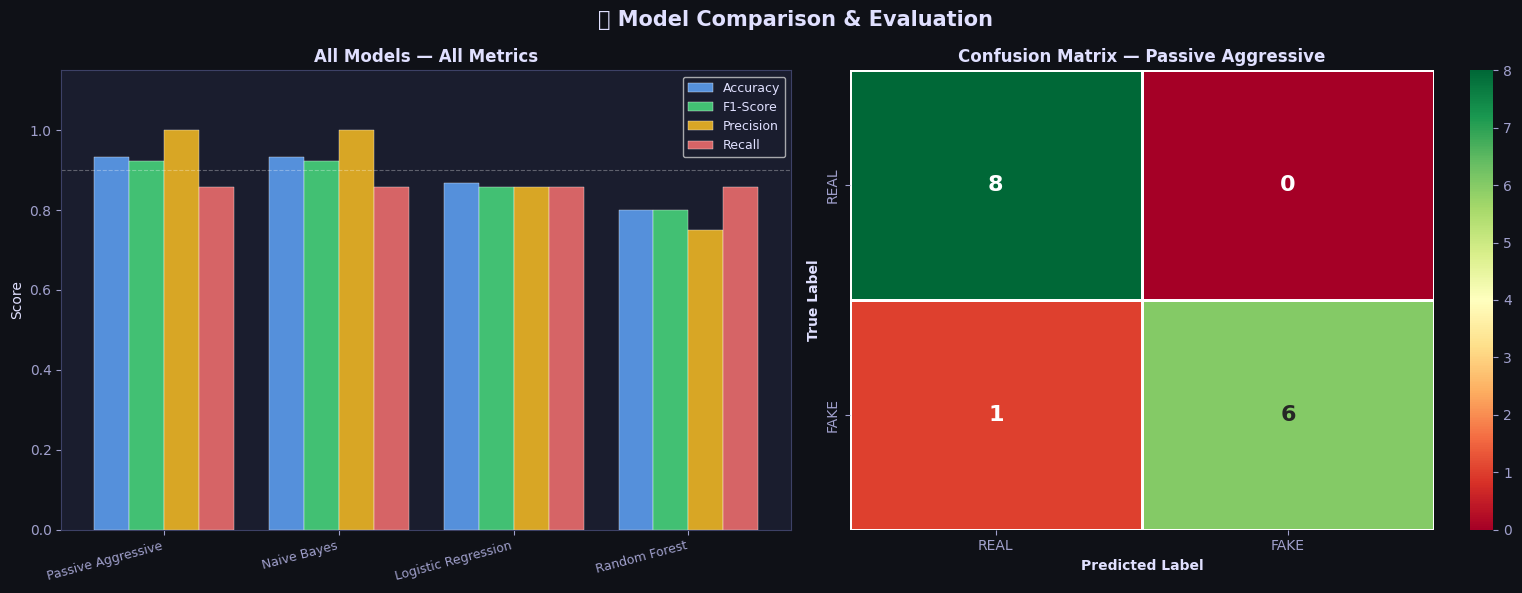


📋 Full Classification Report:
              precision    recall  f1-score   support

        REAL       0.89      1.00      0.94         8
        FAKE       1.00      0.86      0.92         7

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



In [9]:
# ── Model Comparison Visualization ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🤖 Model Comparison & Evaluation', fontsize=15, fontweight='bold', color='#e0e0ff')

# Bar chart comparison
ax = axes[0]
metric_colors = ['#60a5fa', '#4ade80', '#fbbf24', '#f87171']
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(results_df))
width = 0.2

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85, edgecolor='white', linewidth=0.3)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('All Models — All Metrics', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0.9, color='white', linestyle='--', alpha=0.3, linewidth=0.8)

# Confusion Matrix for best model
ax = axes[1]
y_pred_best = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm, annot=True, fmt='d', ax=ax,
    cmap='RdYlGn', linewidths=2,
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE'],
    annot_kws={'size': 16, 'weight': 'bold'}
)
ax.set_xlabel('Predicted Label', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\n📋 Full Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['REAL', 'FAKE']))

---
##  6: Feature Importance & Interpretability

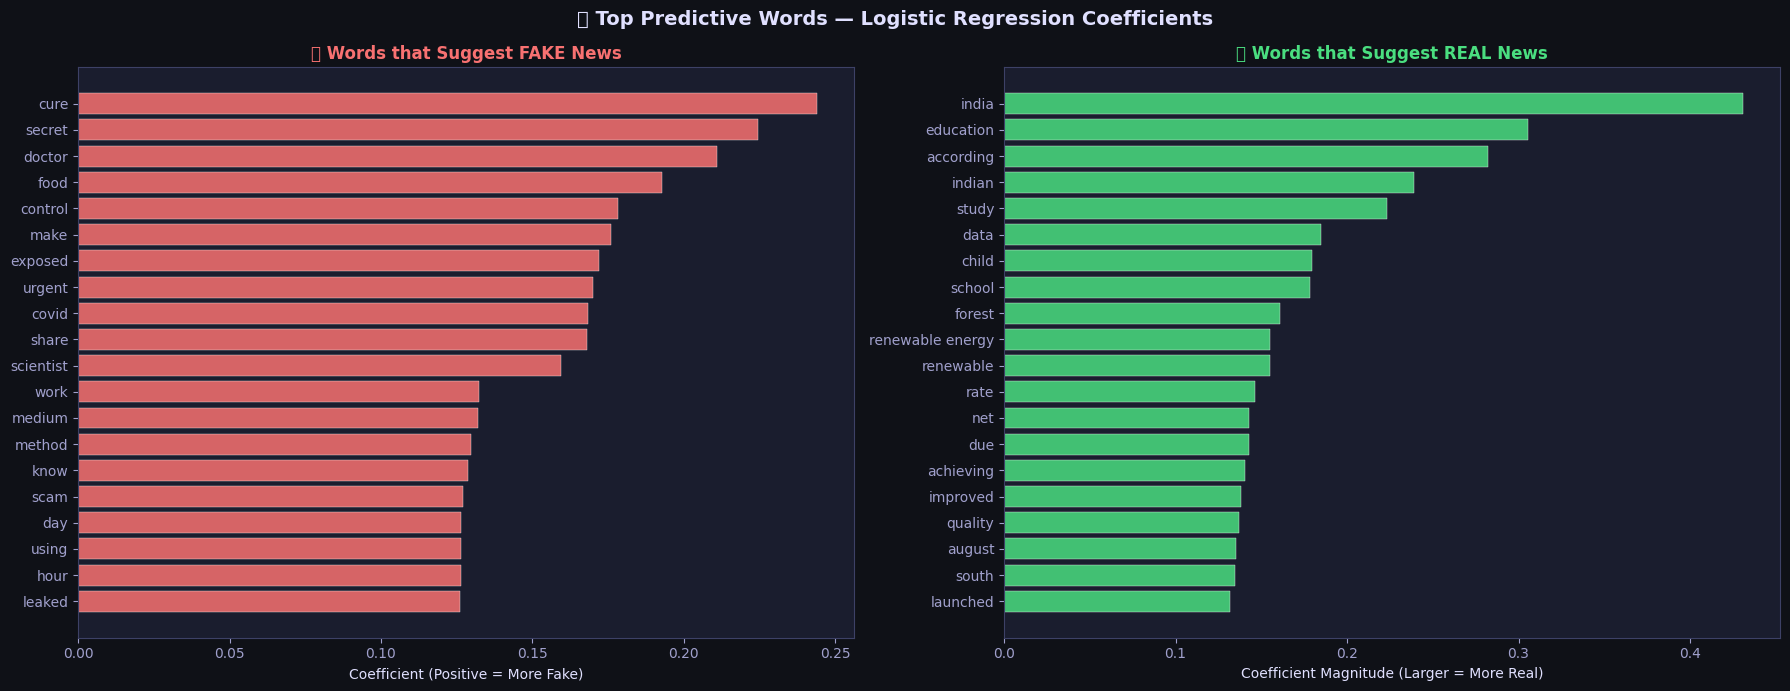

In [10]:
# ── Top TF-IDF Features for Fake vs Real ──────────────────────────────────

# Use Logistic Regression for interpretability
lr_model = trained_models['Logistic Regression']
feature_names = tfidf.get_feature_names_out()
coef = lr_model.coef_[0]

# Top features
top_n = 20
top_fake_idx = np.argsort(coef)[-top_n:][::-1]
top_real_idx = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🔍 Top Predictive Words — Logistic Regression Coefficients', fontsize=14, fontweight='bold', color='#e0e0ff')

# Top FAKE features
ax = axes[0]
fake_features = [feature_names[i] for i in top_fake_idx]
fake_coefs = [coef[i] for i in top_fake_idx]
bars = ax.barh(range(top_n), fake_coefs[::-1], color='#f87171', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_yticks(range(top_n))
ax.set_yticklabels(fake_features[::-1], fontsize=10)
ax.set_title('❌ Words that Suggest FAKE News', fontweight='bold', color='#f87171')
ax.set_xlabel('Coefficient (Positive = More Fake)')
ax.axvline(x=0, color='white', linewidth=0.5)

# Top REAL features
ax = axes[1]
real_features = [feature_names[i] for i in top_real_idx]
real_coefs = [coef[i] for i in top_real_idx]
bars = ax.barh(range(top_n), [abs(c) for c in real_coefs[::-1]], color='#4ade80', alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_yticks(range(top_n))
ax.set_yticklabels(real_features[::-1], fontsize=10)
ax.set_title('✅ Words that Suggest REAL News', fontweight='bold', color='#4ade80')
ax.set_xlabel('Coefficient Magnitude (Larger = More Real)')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
##  7: Complete Fake News Detector System

This is the **main detection engine** — paste any news article or headline below to analyze it!

In [11]:
# ── Full Credibility Analysis System ──────────────────────────────────────

def generate_summary(text, num_sentences=2):
    """Extractive summarization using sentence scoring"""
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text

    # Score sentences by word frequency
    words = word_tokenize(text.lower())
    word_freq = Counter([w for w in words if w not in stop_words_list and w.isalpha()])

    sentence_scores = {}
    for sent in sentences:
        for word in word_tokenize(sent.lower()):
            if word in word_freq:
                sentence_scores[sent] = sentence_scores.get(sent, 0) + word_freq[word]

    top_sentences = sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:num_sentences]
    # Preserve original order
    summary = ' '.join([s for s in sentences if s in top_sentences])
    return summary


def analyze_article(text, verbose=True):
    """
    Comprehensive fake news detection and credibility analysis.
    Returns a detailed credibility report.
    """
    DIVIDER = '═' * 65
    THIN    = '─' * 65

    # ── Preprocessing ──
    clean = preprocess_text(text)
    tfidf_vec = tfidf.transform([clean])

    # ── ML Prediction (ensemble) ──
    votes_fake = 0
    model_preds = {}
    for mname, mobj in trained_models.items():
        pred = mobj.predict(tfidf_vec)[0]
        model_preds[mname] = 'FAKE' if pred == 1 else 'REAL'
        if pred == 1:
            votes_fake += 1
    ml_verdict = 'FAKE' if votes_fake >= 2 else 'REAL'

    # Best model probability (Logistic Regression)
    lr = trained_models['Logistic Regression']
    ml_prob_fake = lr.predict_proba(tfidf_vec)[0][1]

    # ── Linguistic Features ──
    polarity, subjectivity = get_sentiment(text)
    excl_count     = text.count('!')
    caps_ratio     = sum(1 for c in text if c.isupper()) / max(len(text), 1)
    clickbait      = len(re.findall(r'\b(shocking|bombshell|exposed|secret|urgent|breaking|proof|hoax|conspiracy|wake up|share before|hidden|miracle|cure|guaranteed|big pharma|illuminati|sheeple|deleted|suppressed)\b', text, re.I))
    credibility    = len(re.findall(r'\b(according to|published|study|research|journal|percent|data|report|evidence|university|institute|peer.reviewed|lancet|who|nasa|isro|government|official)\b', text, re.I))
    has_stats      = bool(re.search(r'\d+\.?\d*\s*(%|percent|billion|million|crore|lakh)', text, re.I))
    all_caps_words = len(re.findall(r'\b[A-Z]{3,}\b', text))

    # ── Credibility Scoring (0–100) ──
    score = 50.0  # neutral base

    # ML signal (heavy weight)
    score -= (ml_prob_fake - 0.5) * 60

    # Linguistic penalties / bonuses
    score -= min(excl_count * 6, 20)        # exclamation marks hurt credibility
    score -= min(caps_ratio * 120, 20)       # excessive CAPS hurts credibility
    score -= min(clickbait * 8, 24)          # clickbait words hurt credibility
    score -= min(all_caps_words * 4, 16)     # all-caps words hurt credibility
    score += min(credibility * 6, 20)        # source citations boost credibility
    score += (10 if has_stats else 0)        # statistics boost credibility
    score -= min(max(subjectivity - 0.5, 0) * 30, 15)  # high subjectivity hurts

    # Ensemble vote adjustment
    if votes_fake >= 3:
        score -= 15
    elif votes_fake == 0:
        score += 10

    credibility_score = max(0, min(100, score))

    # ── Final Verdict ──
    if credibility_score >= 70:
        verdict = '✅ LIKELY REAL'
        verdict_color = 'GREEN'
        risk_level = 'LOW RISK'
    elif credibility_score >= 45:
        verdict = '⚠️  UNCERTAIN / VERIFY'
        verdict_color = 'YELLOW'
        risk_level = 'MEDIUM RISK'
    else:
        verdict = '❌ LIKELY FAKE'
        verdict_color = 'RED'
        risk_level = 'HIGH RISK'

    # ── Summary ──
    summary = generate_summary(text)

    # ── Red Flags ──
    flags = []
    if excl_count >= 2:       flags.append(f"🚨 High punctuation excitement ({excl_count} '!' marks)")
    if caps_ratio > 0.08:     flags.append(f"🚨 Excessive capital letters ({caps_ratio*100:.0f}% caps)")
    if clickbait >= 1:        flags.append(f"🚨 Clickbait/sensational language detected ({clickbait} trigger words)")
    if all_caps_words >= 2:   flags.append(f"🚨 ALL-CAPS words used ({all_caps_words} instances)")
    if subjectivity > 0.6:    flags.append(f"🚨 Highly subjective writing (score: {subjectivity:.2f}/1.0)")
    if credibility == 0:      flags.append("🚨 No credible sources or institutions cited")
    if not has_stats:         flags.append("ℹ️  No verifiable statistics or data points found")
    if ml_prob_fake > 0.6:    flags.append(f"🤖 ML model confidence: {ml_prob_fake*100:.0f}% likely fake")

    # ── Green Flags ──
    positives = []
    if credibility >= 2:      positives.append(f"✅ Cites credible sources/institutions ({credibility} references)")
    if has_stats:             positives.append("✅ Contains verifiable statistics or data")
    if excl_count == 0:       positives.append("✅ Measured tone — no sensational punctuation")
    if caps_ratio < 0.03:     positives.append("✅ Normal capitalization pattern")
    if subjectivity < 0.4:    positives.append(f"✅ Objective writing style (subjectivity: {subjectivity:.2f}/1.0)")
    if ml_prob_fake < 0.4:    positives.append(f"✅ ML model confidence: {(1-ml_prob_fake)*100:.0f}% likely real")

    if verbose:
        print(f"\n{DIVIDER}")
        print(f"  🛡️  FAKE NEWS DETECTOR — CREDIBILITY REPORT")
        print(f"{DIVIDER}")
        print(f"  VERDICT : {verdict}")
        print(f"  RISK    : {risk_level}")
        print(f"  SCORE   : {credibility_score:.1f} / 100  {'█' * int(credibility_score//5)}{'░' * (20 - int(credibility_score//5))}")
        print(f"{THIN}")

        print(f"\n  📝 ARTICLE SUMMARY:")
        print(f"  {textwrap.fill(summary, width=60, subsequent_indent='  ')}")

        print(f"\n{THIN}")
        print(f"  🤖 ML ENSEMBLE RESULTS ({votes_fake}/{len(trained_models)} models say FAKE):")
        for m, p in model_preds.items():
            icon = '❌' if p == 'FAKE' else '✅'
            print(f"    {icon} {m:<28}: {p}")

        print(f"\n{THIN}")
        print(f"  📊 LINGUISTIC ANALYSIS:")
        print(f"    • Sentiment Polarity    : {polarity:+.3f}  ({'Positive' if polarity > 0 else 'Negative' if polarity < 0 else 'Neutral'})")
        print(f"    • Subjectivity          : {subjectivity:.3f}  ({'Objective' if subjectivity < 0.4 else 'Subjective'})")
        print(f"    • Exclamation Marks     : {excl_count}")
        print(f"    • ALL-CAPS Words        : {all_caps_words}")
        print(f"    • Clickbait Triggers    : {clickbait}")
        print(f"    • Credibility Signals   : {credibility}")
        print(f"    • Contains Statistics   : {'Yes' if has_stats else 'No'}")

        if flags:
            print(f"\n{THIN}")
            print(f"  🚩 RED FLAGS DETECTED:")
            for f in flags:
                print(f"    {f}")

        if positives:
            print(f"\n  🟢 CREDIBILITY SIGNALS:")
            for p in positives:
                print(f"    {p}")

        print(f"\n{THIN}")
        print(f"  💡 ADVICE FOR STUDENTS:")
        if credibility_score < 45:
            print(f"    → Do NOT share this content without verification.")
            print(f"    → Cross-check with trusted sources: BBC, Reuters, PIB India.")
            print(f"    → Look for the original source and author credentials.")
        elif credibility_score < 70:
            print(f"    → Verify with at least 2 independent credible sources.")
            print(f"    → Check if reputable news outlets have reported the same story.")
        else:
            print(f"    → Article appears credible, but always verify before sharing.")
            print(f"    → Good practice: check the publication date and author.")

        print(f"{DIVIDER}\n")

    return {
        'verdict': verdict,
        'credibility_score': credibility_score,
        'summary': summary,
        'ml_verdict': ml_verdict,
        'model_preds': model_preds,
        'flags': flags,
        'positives': positives
    }

print("✅ Detection system initialized! Ready to analyze articles.")

✅ Detection system initialized! Ready to analyze articles.


---
##  8: Live Demo — Test with Real Examples

In [12]:
# ── Demo Article 1: FAKE News ──────────────────────────────────────────────

fake_article = """
SHOCKING: Scientists PROVE that COVID vaccines contain microchips!!
The government is tracking your every move through 5G towers!
Big Pharma EXPOSED: They are hiding the MIRACLE CURE that eliminates the virus in 3 days!
URGENT: Share this before it gets DELETED! The truth is being suppressed!
Wake up sheeple! The illuminati and globalist elite are controlling your mind through vaccines!
BOMBSHELL: 50,000 doctors secretly signed a petition but mainstream media refuses to cover it!
"""

result1 = analyze_article(fake_article)


═════════════════════════════════════════════════════════════════
  🛡️  FAKE NEWS DETECTOR — CREDIBILITY REPORT
═════════════════════════════════════════════════════════════════
  VERDICT : ❌ LIKELY FAKE
  RISK    : HIGH RISK
  SCORE   : 0.0 / 100  ░░░░░░░░░░░░░░░░░░░░
─────────────────────────────────────────────────────────────────

  📝 ARTICLE SUMMARY:
  Big Pharma EXPOSED: They are hiding the MIRACLE CURE that
  eliminates the virus in 3 days! BOMBSHELL: 50,000 doctors
  secretly signed a petition but mainstream media refuses to
  cover it!

─────────────────────────────────────────────────────────────────
  🤖 ML ENSEMBLE RESULTS (4/4 models say FAKE):
    ❌ Logistic Regression         : FAKE
    ❌ Passive Aggressive          : FAKE
    ❌ Naive Bayes                 : FAKE
    ❌ Random Forest               : FAKE

─────────────────────────────────────────────────────────────────
  📊 LINGUISTIC ANALYSIS:
    • Sentiment Polarity    : -0.500  (Negative)
    • Subjectivity          :

In [13]:
# ── Demo Article 2: REAL News ──────────────────────────────────────────────

real_article = """
India's ISRO successfully conducted the Chandrayaan-3 lunar mission, achieving a historic
soft landing near the moon's south pole on August 23, 2023. According to ISRO officials,
the Vikram lander and Pragyan rover are functioning normally. The mission cost approximately
Rs 600 crore, significantly less than comparable international missions. Scientists from
the Indian Institute of Space Science and Technology confirm that preliminary data from
the rover's spectrometers indicates the presence of sulfur and other elements in the lunar soil.
The European Space Agency has also acknowledged the mission's success in a published statement.
"""

result2 = analyze_article(real_article)


═════════════════════════════════════════════════════════════════
  🛡️  FAKE NEWS DETECTOR — CREDIBILITY REPORT
═════════════════════════════════════════════════════════════════
  VERDICT : ✅ LIKELY REAL
  RISK    : LOW RISK
  SCORE   : 82.1 / 100  ████████████████░░░░
─────────────────────────────────────────────────────────────────

  📝 ARTICLE SUMMARY:
   India's ISRO successfully conducted the Chandrayaan-3 lunar
  mission, achieving a historic  soft landing near the
  moon's south pole on August 23, 2023. Scientists from  the
  Indian Institute of Space Science and Technology confirm
  that preliminary data from  the rover's spectrometers
  indicates the presence of sulfur and other elements in the
  lunar soil.

─────────────────────────────────────────────────────────────────
  🤖 ML ENSEMBLE RESULTS (0/4 models say FAKE):
    ✅ Logistic Regression         : REAL
    ✅ Passive Aggressive          : REAL
    ✅ Naive Bayes                 : REAL
    ✅ Random Forest               :

In [14]:
# ── Demo Article 3: Try Your OWN Article! ─────────────────────────────────

# ✏️  PASTE ANY NEWS ARTICLE OR HEADLINE HERE:
your_article = """
Paste any news article, WhatsApp message, social media post, or headline here.
The system will analyze it for credibility and tell you if it's likely real or fake.
You can try copying a viral WhatsApp message or a news headline you're unsure about.
"""

result3 = analyze_article(your_article)


═════════════════════════════════════════════════════════════════
  🛡️  FAKE NEWS DETECTOR — CREDIBILITY REPORT
═════════════════════════════════════════════════════════════════
  VERDICT : ❌ LIKELY FAKE
  RISK    : HIGH RISK
  SCORE   : 22.3 / 100  ████░░░░░░░░░░░░░░░░
─────────────────────────────────────────────────────────────────

  📝 ARTICLE SUMMARY:
   Paste any news article, WhatsApp message, social media
  post, or headline here. You can try copying a viral
  WhatsApp message or a news headline you're unsure about.

─────────────────────────────────────────────────────────────────
  🤖 ML ENSEMBLE RESULTS (4/4 models say FAKE):
    ❌ Logistic Regression         : FAKE
    ❌ Passive Aggressive          : FAKE
    ❌ Naive Bayes                 : FAKE
    ❌ Random Forest               : FAKE

─────────────────────────────────────────────────────────────────
  📊 LINGUISTIC ANALYSIS:
    • Sentiment Polarity    : -0.239  (Negative)
    • Subjectivity          : 0.689  (Subjective)


---
##  9: Batch Analysis & Credibility Dashboard

In [15]:
# ── Batch Analysis Dashboard ───────────────────────────────────────────────

test_headlines = [
    ("Scientists at WHO confirm new COVID variant under surveillance", "REAL"),
    ("SHOCKING: Bill Gates admits vaccine is MIND CONTROL device!!", "FAKE"),
    ("India's GDP grows at 7.2% in FY2023, says government report", "REAL"),
    ("EXPOSED: Moon landing was filmed in Hollywood studio by Kubrick!", "FAKE"),
    ("IIT Bombay researchers publish study on renewable energy in Nature journal", "REAL"),
    ("Drinking hot water KILLS coronavirus instantly!! Share before deleted!", "FAKE"),
    ("RBI raises interest rates by 25 basis points to control inflation", "REAL"),
    ("Alien spacecraft LANDED in Rajasthan!! Government covering up TRUTH!!!", "FAKE"),
]

batch_results = []
print("🔍 Batch Analyzing Headlines...\n")

for headline, true_label in test_headlines:
    r = analyze_article(headline, verbose=False)
    predicted = 'FAKE' if r['credibility_score'] < 50 else 'REAL'
    correct = '✅' if predicted == true_label else '❌'
    batch_results.append({
        'Headline': headline[:55] + '...' if len(headline) > 55 else headline,
        'True Label': true_label,
        'Predicted': predicted,
        'Score': f"{r['credibility_score']:.0f}/100",
        'Correct': correct
    })
    print(f"{correct} [{r['credibility_score']:5.1f}] {headline[:60]}")

batch_df = pd.DataFrame(batch_results)
print(f"\n📊 Batch Accuracy: {batch_df[batch_df['Correct']=='✅'].shape[0]}/{len(batch_df)} ({batch_df[batch_df['Correct']=='✅'].shape[0]/len(batch_df)*100:.0f}%)")

🔍 Batch Analyzing Headlines...

❌ [ 12.0] Scientists at WHO confirm new COVID variant under surveillan
✅ [  0.0] SHOCKING: Bill Gates admits vaccine is MIND CONTROL device!!
✅ [ 69.0] India's GDP grows at 7.2% in FY2023, says government report
✅ [  0.0] EXPOSED: Moon landing was filmed in Hollywood studio by Kubr
✅ [ 63.1] IIT Bombay researchers publish study on renewable energy in 
✅ [  0.0] Drinking hot water KILLS coronavirus instantly!! Share befor
❌ [ 24.5] RBI raises interest rates by 25 basis points to control infl
✅ [  0.0] Alien spacecraft LANDED in Rajasthan!! Government covering u

📊 Batch Accuracy: 6/8 (75%)


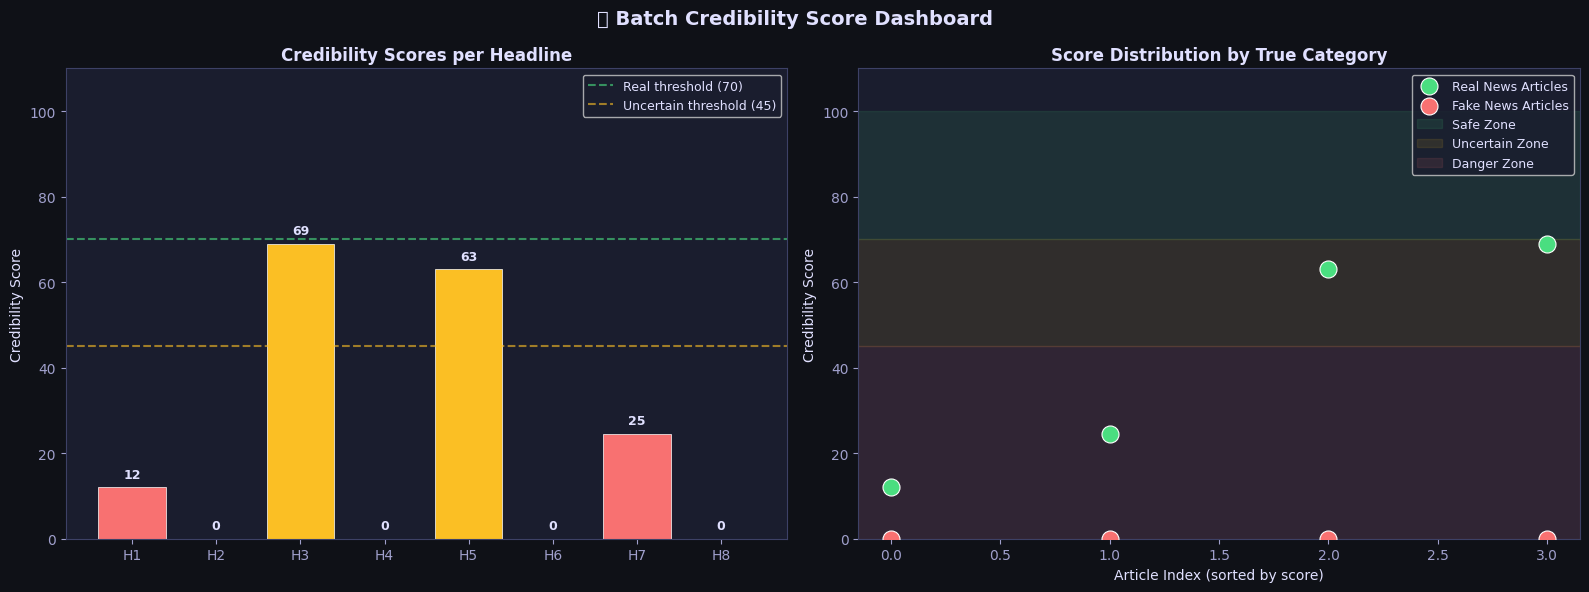

In [16]:
# ── Credibility Score Visualization ───────────────────────────────────────

scores = []
labels_list = []
for headline, true_label in test_headlines:
    r = analyze_article(headline, verbose=False)
    scores.append(r['credibility_score'])
    labels_list.append(true_label)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📊 Batch Credibility Score Dashboard', fontsize=14, fontweight='bold', color='#e0e0ff')

# Score bar chart
ax = axes[0]
bar_colors = ['#4ade80' if s >= 70 else '#fbbf24' if s >= 45 else '#f87171' for s in scores]
short_labels = [f"H{i+1}" for i in range(len(test_headlines))]
bars = ax.bar(short_labels, scores, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=70, color='#4ade80', linestyle='--', alpha=0.6, linewidth=1.5, label='Real threshold (70)')
ax.axhline(y=45, color='#fbbf24', linestyle='--', alpha=0.6, linewidth=1.5, label='Uncertain threshold (45)')
ax.set_ylim(0, 110)
ax.set_ylabel('Credibility Score')
ax.set_title('Credibility Scores per Headline', fontweight='bold')
ax.legend(fontsize=9)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{score:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Score gauge-style pie
ax = axes[1]
real_scores  = [s for s, l in zip(scores, labels_list) if l == 'REAL']
fake_scores  = [s for s, l in zip(scores, labels_list) if l == 'FAKE']
ax.scatter(range(len(real_scores)), sorted(real_scores), color='#4ade80', s=150,
           label='Real News Articles', zorder=5, edgecolors='white', linewidth=0.8)
ax.scatter(range(len(fake_scores)), sorted(fake_scores), color='#f87171', s=150,
           label='Fake News Articles', zorder=5, edgecolors='white', linewidth=0.8)
ax.axhspan(70, 100, alpha=0.1, color='#4ade80', label='Safe Zone')
ax.axhspan(45, 70,  alpha=0.1, color='#fbbf24', label='Uncertain Zone')
ax.axhspan(0, 45,   alpha=0.1, color='#f87171',  label='Danger Zone')
ax.set_ylabel('Credibility Score')
ax.set_title('Score Distribution by True Category', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 110)
ax.set_xlabel('Article Index (sorted by score)')

plt.tight_layout()
plt.savefig('credibility_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
##  10: Tips for Students — How to Spot Fake News

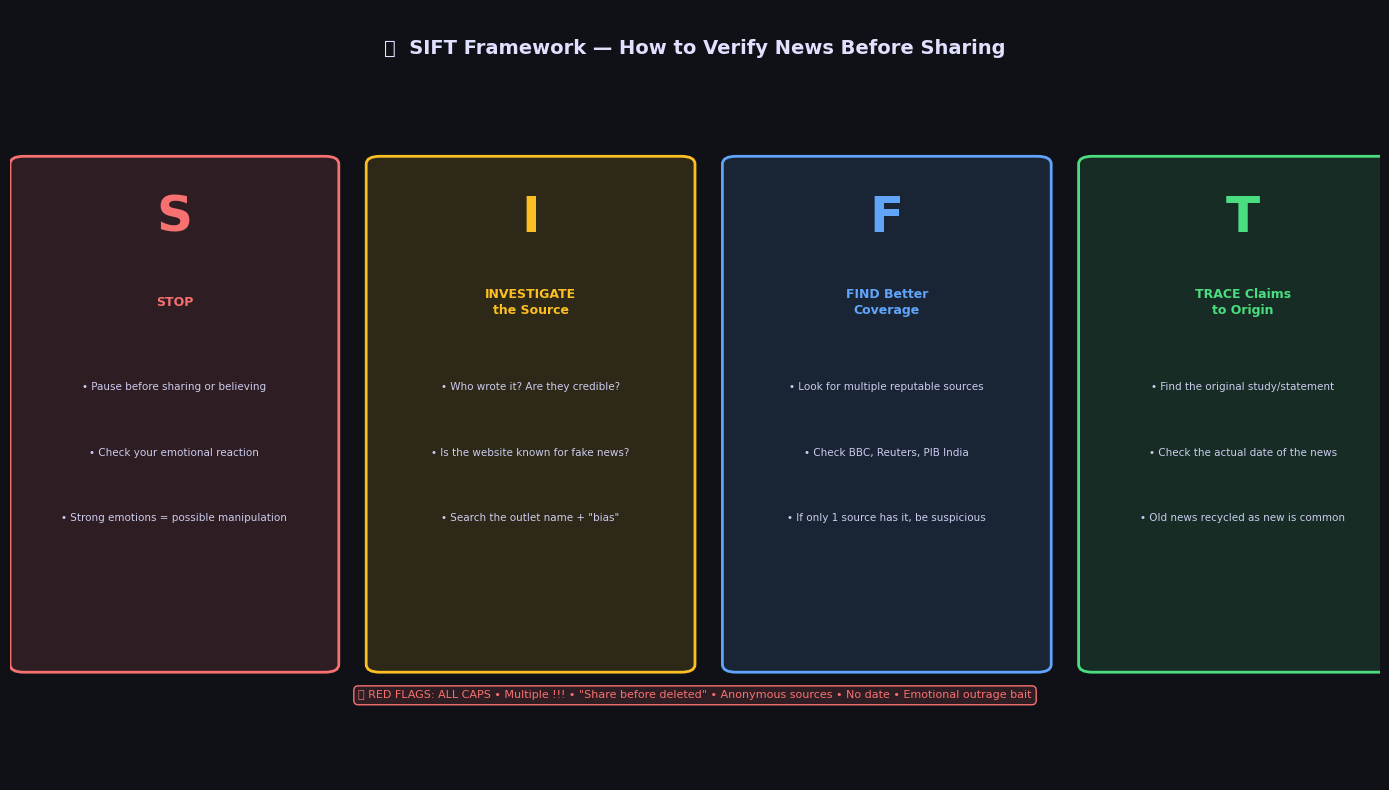


🌐 Trusted Fact-Checking Resources for Indian Students:
   • PIB Fact Check  : https://factcheck.pib.gov.in
   • Boom Live        : https://www.boomlive.in
   • Alt News         : https://www.altnews.in
   • Snopes           : https://www.snopes.com
   • Reuters Fact Check: https://www.reuters.com/fact-check


In [17]:
# ── Student Education: SIFT Framework Visualization ───────────────────────

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, '🛡️  SIFT Framework — How to Verify News Before Sharing',
        ha='center', va='center', fontsize=14, fontweight='bold', color='#e0e0ff')

sift_data = [
    ('S', 'STOP', '#f87171',
     ['• Pause before sharing or believing', '• Check your emotional reaction', '• Strong emotions = possible manipulation'],
     1.2),
    ('I', 'INVESTIGATE\nthe Source', '#fbbf24',
     ['• Who wrote it? Are they credible?', '• Is the website known for fake news?', '• Search the outlet name + "bias"'],
     3.8),
    ('F', 'FIND Better\nCoverage', '#60a5fa',
     ['• Look for multiple reputable sources', '• Check BBC, Reuters, PIB India', '• If only 1 source has it, be suspicious'],
     6.4),
    ('T', 'TRACE Claims\nto Origin', '#4ade80',
     ['• Find the original study/statement', '• Check the actual date of the news', '• Old news recycled as new is common'],
     9.0),
]

for letter, title, color, points, x_pos in sift_data:
    # Box
    rect = mpatches.FancyBboxPatch((x_pos - 1.1, 1.5), 2.2, 6.5,
                                    boxstyle='round,pad=0.1',
                                    facecolor=color + '22', edgecolor=color,
                                    linewidth=2)
    ax.add_patch(rect)
    # Big Letter
    ax.text(x_pos, 7.3, letter, ha='center', va='center',
            fontsize=36, fontweight='bold', color=color)
    # Title
    ax.text(x_pos, 6.2, title, ha='center', va='center',
            fontsize=9, fontweight='bold', color=color, linespacing=1.3)
    # Points
    for i, pt in enumerate(points):
        ax.text(x_pos, 5.1 - i * 0.85, pt, ha='center', va='center',
                fontsize=7.5, color='#ccccee', linespacing=1.2)

# Red flags box
ax.text(5, 1.1, '🚨 RED FLAGS: ALL CAPS • Multiple !!! • "Share before deleted" • Anonymous sources • No date • Emotional outrage bait',
        ha='center', va='center', fontsize=8, color='#f87171',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8717122', edgecolor='#f87171', linewidth=1))

plt.tight_layout()
plt.savefig('sift_framework.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\n🌐 Trusted Fact-Checking Resources for Indian Students:")
print("   • PIB Fact Check  : https://factcheck.pib.gov.in")
print("   • Boom Live        : https://www.boomlive.in")
print("   • Alt News         : https://www.altnews.in")
print("   • Snopes           : https://www.snopes.com")
print("   • Reuters Fact Check: https://www.reuters.com/fact-check")